Using the **Breast Cancer Wisconsin dataset** — built into scikit-learn, binary classification (malignant=0 / benign=1), 30 real features. Same task structure as SECOM (binary classification on real sensor/measurement features) — swap in your own SECOM data later using this same code structure.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

data = load_breast_cancer()
X, y = data.data, data.target      # X shape (569, 30), y shape (569,) — binary 0/1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# scale — logistic regression (both manual and sklearn) is sensitive to feature scale, same reason as linear regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # transform only — use training set's mu, sigma


Applies the sigmoid model, log-loss cost, and gradient formulas directly — the gradient has the same *form* as linear regression's, just with `f_wb` computed via sigmoid instead of a raw linear combination.

In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_gradient_logistic(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    f_wb = sigmoid(z)
    err = f_wb - y                      # same shape as the linear regression err vector
    dj_dw = (X.T @ err) / m             # identical structure to linear regression's gradient
    dj_db = np.sum(err) / m
    return dj_dw, dj_db

def gradient_descent_logistic(X, y, w_in, b_in, alpha, num_iters):
    w = w_in.copy()
    b = b_in
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_logistic(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
    return w, b

n_features = X_train_scaled.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0

w_manual, b_manual = gradient_descent_logistic(X_train_scaled, y_train, w_init, b_init, alpha=0.1, num_iters=1000)

z_test = X_test_scaled @ w_manual + b_manual
proba_manual = sigmoid(z_test)
pred_manual = (proba_manual >= 0.5).astype(int)

accuracy_manual = np.mean(pred_manual == y_test)
print(f"Manual sigmoid + gradient descent — test accuracy: {accuracy_manual:.3f}")

Manual sigmoid + gradient descent — test accuracy: 0.974


Same task, same scaled data — using scikit-learn's built-in solver instead of your own gradient descent loop.

In [17]:
sk_model = LogisticRegression()
sk_model.fit(X_train_scaled, y_train)

pred_sklearn = sk_model.predict(X_test_scaled)
proba_sklearn = sk_model.predict_proba(X_test_scaled)[:,1]
accuracy_sklearn = np.mean(pred_sklearn == y_test)
print(f"Scikit-learn LogisticRegression — test accuracy: {accuracy_sklearn:.3f}")

Scikit-learn LogisticRegression — test accuracy: 0.974


In [18]:
print(f"Manual w (first 5):    {w_manual[:5]}")
print(f"Sklearn w (first 5):   {sk_model.coef_[0][:5]}")
print(f"Manual b:  {b_manual:.3f}")
print(f"Sklearn b: {sk_model.intercept_[0]:.3f}")
print(f"Accuracy — manual: {accuracy_manual:.3f} | sklearn: {accuracy_sklearn:.3f}")

Manual w (first 5):    [-0.59602101 -0.57711928 -0.58170463 -0.60751891 -0.19596506]
Sklearn w (first 5):   [-0.43458075 -0.42339927 -0.41846885 -0.44954044 -0.20224574]
Manual b:  0.431
Sklearn b: 0.228
Accuracy — manual: 0.974 | sklearn: 0.974


**Confusion matrix** — counts of correct vs incorrect predictions by class: true positives, true negatives, false positives, false negatives. More informative than accuracy alone — especially relevant in a fab context, where false negatives (missed defects) and false positives (false alarms) carry different costs.

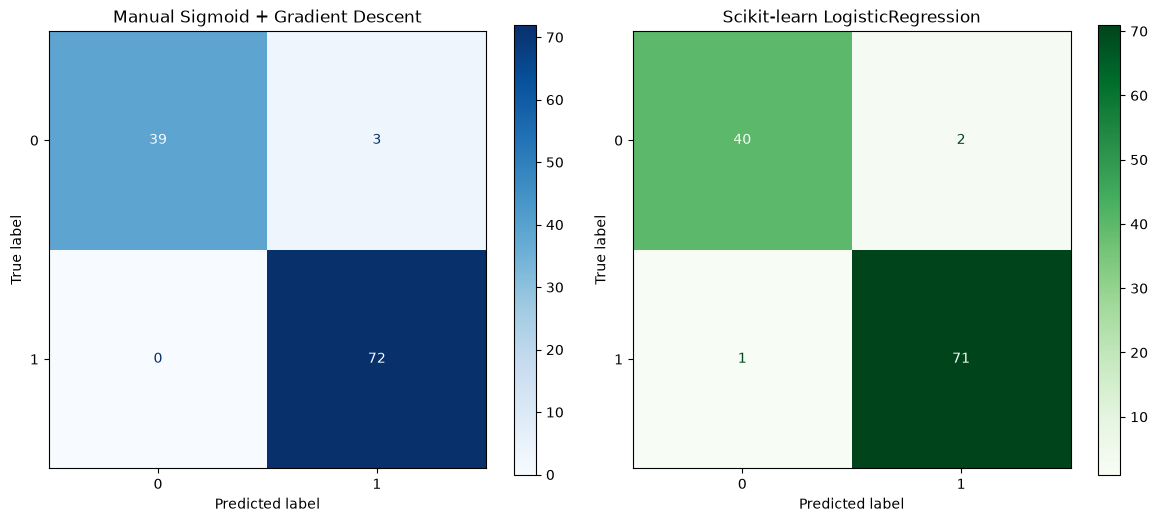

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, pred_manual, ax=axes[0], cmap='Blues')
axes[0].set_title('Manual Sigmoid + Gradient Descent')

ConfusionMatrixDisplay.from_predictions(y_test, pred_sklearn, ax=axes[1], cmap='Greens')
axes[1].set_title('Scikit-learn LogisticRegression')

plt.tight_layout()
plt.show()

**ROC curve** — plots true positive rate vs. false positive rate as the classification threshold is swept (not just the default 0.5). **AUC** summarizes it as one number: 1.0 = perfect, 0.5 = random guessing. Uses `predict_proba` output, not hard 0/1 labels, which is why the sigmoid's continuous probability output matters, not just the final class.

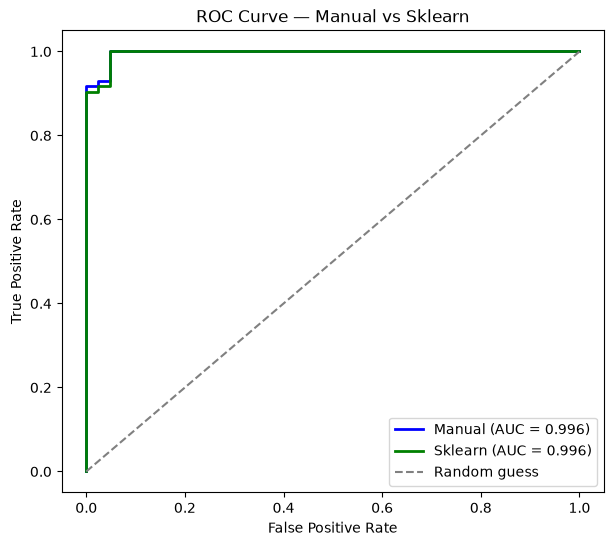

In [20]:
fpr_manual, tpr_manual, _ = roc_curve(y_test, proba_manual)
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, proba_sklearn)

auc_manual = auc(fpr_manual, tpr_manual)
auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

plt.figure(figsize=(7, 6))
plt.plot(fpr_manual, tpr_manual, color='blue', label=f'Manual (AUC = {auc_manual:.3f})', linewidth=2)
plt.plot(fpr_sklearn, tpr_sklearn, color='green', label=f'Sklearn (AUC = {auc_sklearn:.3f})', linewidth=2)
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Manual vs Sklearn')
plt.legend()
plt.show()

**Sigmoid output histogram** — shows the distribution of predicted probabilities, split by true class. A well-separated model pushes $y=0$ probabilities toward 0 and $y=1$ probabilities toward 1; heavy overlap near 0.5 indicates the model struggles to distinguish the classes.

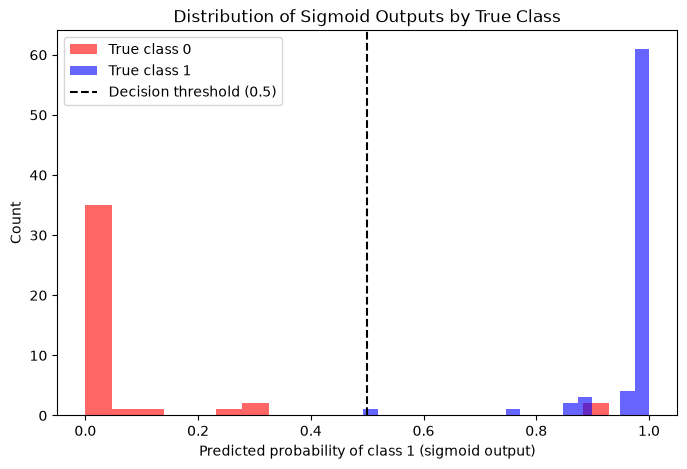

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(proba_sklearn[y_test==0], bins=20, alpha=0.6, color='red', label='True class 0')
plt.hist(proba_sklearn[y_test==1], bins=20, alpha=0.6, color='blue', label='True class 1')
plt.axvline(0.5, color='black', linestyle='--', label='Decision threshold (0.5)')
plt.xlabel('Predicted probability of class 1 (sigmoid output)')
plt.ylabel('Count')
plt.title('Distribution of Sigmoid Outputs by True Class')
plt.legend()
plt.show()

**Coefficient magnitude as feature importance** — since features were z-score scaled, $|w_j|$ is directly comparable across features: larger magnitude means more influence on the prediction. This interpretability is a practical advantage of logistic regression when explaining results to non-technical Fab leadership.

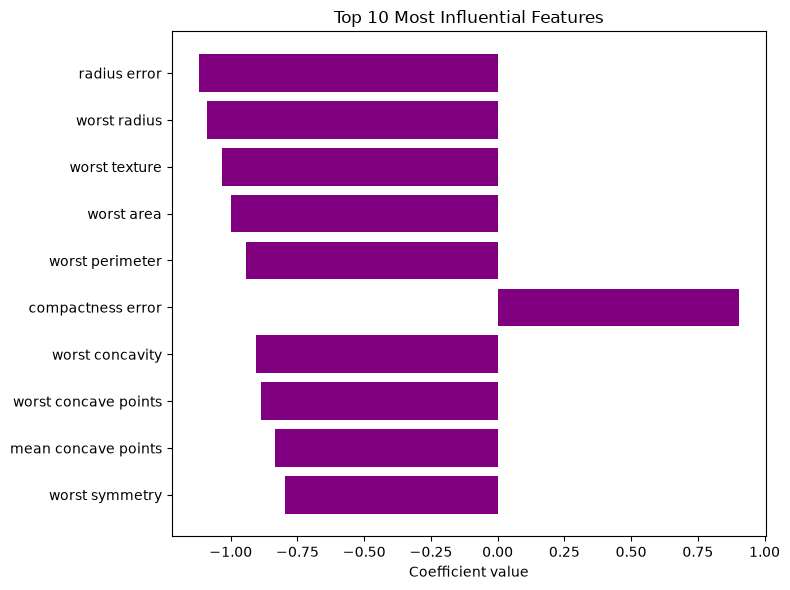

In [22]:
coef = sk_model.coef_[0]
feature_names = data.feature_names

top_n = 10
top_idx = np.argsort(np.abs(coef))[-top_n:]

plt.figure(figsize=(8, 6))
plt.barh(feature_names[top_idx], coef[top_idx], color='purple')
plt.xlabel('Coefficient value')
plt.title(f'Top {top_n} Most Influential Features')
plt.tight_layout()
plt.show()